In [1]:
pip install imdlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install certifi matplotlib numpy pandas python-dateutil pytest pytz urllib3 scipy six xarray

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install geopandas rasterio cartopy folium jupyterlab

   ---------------------------------------- 0.0/30.1 MB ? eta -:--:--
   - -------------------------------------- 1.0/30.1 MB 5.5 MB/s eta 0:00:06
   --- ------------------------------------ 2.4/30.1 MB 5.8 MB/s eta 0:00:05
   ---- ----------------------------------- 3.4/30.1 MB 5.6 MB/s eta 0:00:05
   ------ --------------------------------- 4.7/30.1 MB 5.9 MB/s eta 0:00:05
   -------- ------------------------------- 6.0/30.1 MB 5.8 MB/s eta 0:00:05
   ---------- ----------------------------- 7.6/30.1 MB 6.0 MB/s eta 0:00:04
   ----------- ---------------------------- 8.7/30.1 MB 6.0 MB/s eta 0:00:04
   ------------- -------------------------- 10.0/30.1 MB 6.0 MB/s eta 0:00:04
   -------------- ------------------------- 11.3/30.1 MB 6.0 MB/s eta 0:00:04
   ---------------- ----------------------- 12.3/30.1 MB 5.9 MB/s eta 0:00:03
   ------------------ --------------------- 13.6/30.1 MB 6.0 MB/s eta 0:00:03
   ------------------- -------------------- 14.9/30.1 MB 6.0 MB/s eta 0:00:03
 

In [1]:
import imdlib as imd

tmax = imd.get_data(
    'tmax',
    1975,
    2024,
    fn_format='yearwise'
)

Downloading: maxtemp for year 1975
Downloading: maxtemp for year 1976
Downloading: maxtemp for year 1977
Downloading: maxtemp for year 1978
Downloading: maxtemp for year 1979
Downloading: maxtemp for year 1980
Downloading: maxtemp for year 1981
Downloading: maxtemp for year 1982
Downloading: maxtemp for year 1983
Downloading: maxtemp for year 1984
Downloading: maxtemp for year 1985
Downloading: maxtemp for year 1986
Downloading: maxtemp for year 1987
Downloading: maxtemp for year 1988
Downloading: maxtemp for year 1989
Downloading: maxtemp for year 1990
Downloading: maxtemp for year 1991
Downloading: maxtemp for year 1992
Downloading: maxtemp for year 1993
Downloading: maxtemp for year 1994
Downloading: maxtemp for year 1995
Downloading: maxtemp for year 1996
Downloading: maxtemp for year 1997
Downloading: maxtemp for year 1998
Downloading: maxtemp for year 1999
Downloading: maxtemp for year 2000
Downloading: maxtemp for year 2001
Downloading: maxtemp for year 2002
Downloading: maxtemp

In [2]:
data = imd.open_data(
    'tmax',
    1975,
    2024,
    'yearwise'
)

ds = data.get_xarray()

In [4]:
ds = ds.where(ds['tmax'] != -999) #replacing missing values

In [5]:
summer = ds.sel(
    time=ds.time.dt.month.isin([3,4,5,6])
)

In [6]:
p90 = summer['tmax'].quantile(
    0.90,
    dim='time'
)

In [7]:
p95 = summer['tmax'].quantile(
    0.95,
    dim='time'
)

E:\Anaconda\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


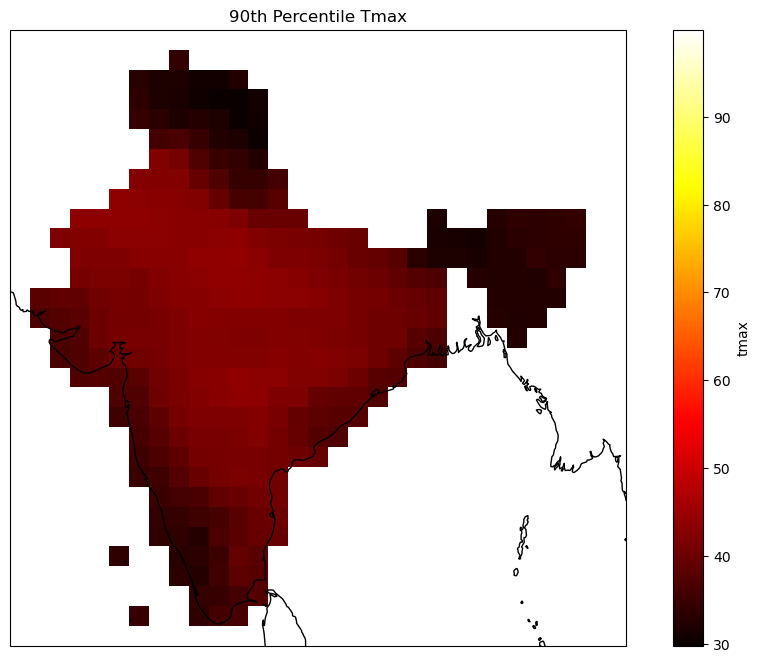

In [8]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12,8))

ax = plt.axes(
    projection=ccrs.PlateCarree()
)

p90.plot(
    ax=ax,
    cmap='hot',
    transform=ccrs.PlateCarree()
)

ax.coastlines()
ax.set_title(
    '90th Percentile Tmax'
)

plt.show()

In [10]:
bbsr = ds.sel(
    lat=20.2961,
    lon=85.8245,
    method='nearest'
)

In [11]:
summer = bbsr.sel(
    time=bbsr.time.dt.month.isin([3,4,5,6])
)

In [12]:
p90 = summer['tmax'].quantile(0.90).values
p95 = summer['tmax'].quantile(0.95).values

print("90th Percentile =", p90)
print("95th Percentile =", p95)

90th Percentile = 37.770162200927736
95th Percentile = 38.414027023315434


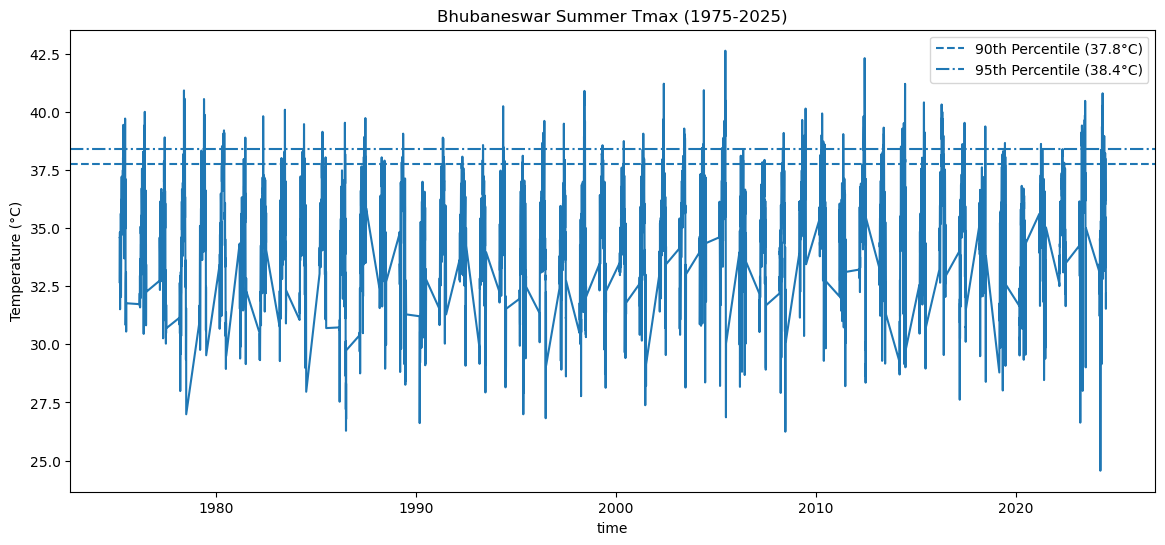

In [15]:
plt.figure(figsize=(14,6))

summer['tmax'].plot()

plt.axhline(
    p90,
    linestyle='--',
    label=f'90th Percentile ({p90:.1f}°C)'
)

plt.axhline(
    p95,
    linestyle='-.',
    label=f'95th Percentile ({p95:.1f}°C)'
)

plt.title(
    'Bhubaneswar Summer Tmax (1975-2025)'
)

plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

In [16]:
heatwave90 = (summer['tmax'] > p90).sum().values
heatwave95 = (summer['tmax'] > p95).sum().values

print("Days above P90:", heatwave90)
print("Days above P95:", heatwave95)

Days above P90: 610
Days above P95: 305


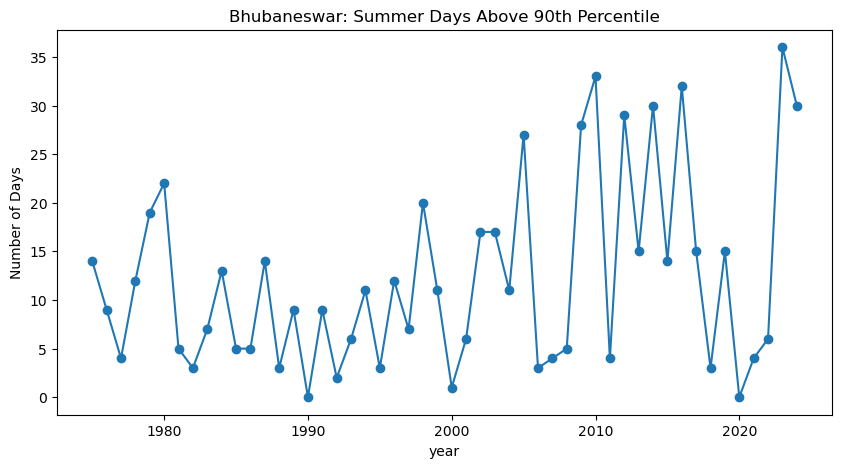

In [17]:
hw_days = (
    (summer['tmax'] > p90)
    .groupby('time.year')
    .sum()
)

hw_days.plot(
    marker='o',
    figsize=(10,5)
)

plt.title(
    'Bhubaneswar: Summer Days Above 90th Percentile'
)

plt.ylabel('Number of Days')
plt.show()

In [24]:
summer = ds.sel(
    time=ds.time.dt.month.isin([3,4,5,6])
)

In [25]:
p90 = summer['tmax'].quantile(
    0.90,
    dim='time'
)

print(p90)

<xarray.DataArray 'tmax' (lat: 31, lon: 31)> Size: 8kB
array([[99.90000153, 99.90000153, 99.90000153, 99.90000153, 99.90000153,
        99.90000153, 99.90000153, 99.90000153, 99.90000153, 99.90000153,
        99.90000153, 99.90000153, 99.90000153, 99.90000153, 99.90000153,
        99.90000153, 99.90000153, 99.90000153, 99.90000153, 99.90000153,
        99.90000153, 99.90000153, 99.90000153, 99.90000153, 99.90000153,
        99.90000153, 99.90000153, 99.90000153, 99.90000153, 99.90000153,
        99.90000153],
       [99.90000153, 99.90000153, 99.90000153, 99.90000153, 99.90000153,
        99.90000153, 34.47000122, 99.90000153, 99.90000153, 33.70000076,
        35.72999954, 36.15000153, 99.90000153, 99.90000153, 99.90000153,
        99.90000153, 99.90000153, 99.90000153, 99.90000153, 99.90000153,
        99.90000153, 99.90000153, 99.90000153, 99.90000153, 99.90000153,
        99.90000153, 99.90000153, 99.90000153, 99.90000153, 99.90000153,
        99.90000153],
       [99.90000153, 99.9

In [26]:
bbsr_map = p90.sel(
    lat=slice(18.5,22.5),
    lon=slice(83.5,87.5)
)

E:\Anaconda\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
E:\Anaconda\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
E:\Anaconda\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_1_states_provinces_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


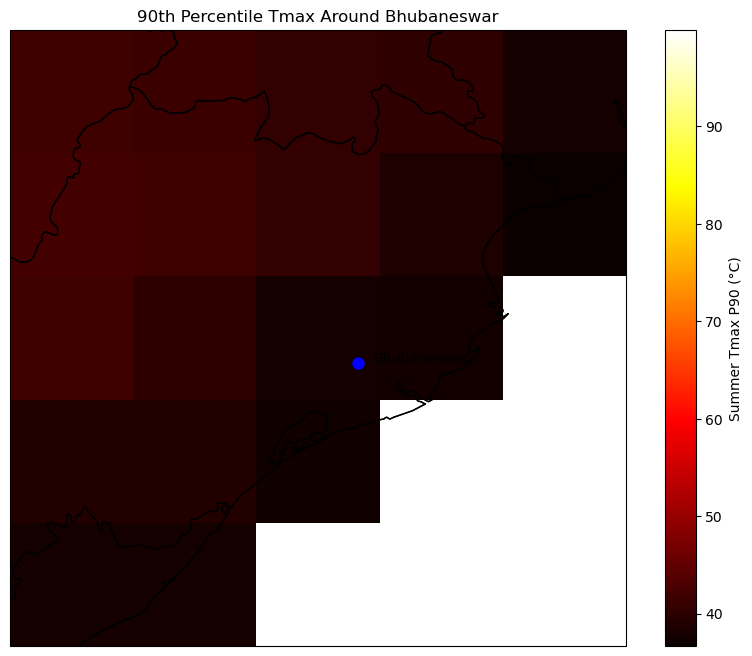

In [27]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(10,8))

ax = plt.axes(
    projection=ccrs.PlateCarree()
)

bbsr_map.plot(
    ax=ax,
    cmap='hot',
    cbar_kwargs={
        'label':'Summer Tmax P90 (°C)'
    }
)

ax.coastlines()
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES)

# Bhubaneswar marker
ax.plot(
    85.8245,
    20.2961,
    'bo',
    markersize=8,
    transform=ccrs.PlateCarree()
)

ax.text(
    85.95,
    20.3,
    'Bhubaneswar',
    transform=ccrs.PlateCarree()
)

plt.title(
    '90th Percentile Tmax Around Bhubaneswar'
)

plt.show()

In [36]:
bbsr_p90 = p90.sel(
    lat=slice(19.0, 21.5),
    lon=slice(84.0, 87.0)
)

In [37]:
from scipy.interpolate import griddata
import numpy as np

lon = bbsr_p90.lon.values
lat = bbsr_p90.lat.values

Lon, Lat = np.meshgrid(lon, lat)

points = np.column_stack(
    (Lon.ravel(), Lat.ravel())
)

values = bbsr_p90.values.ravel()

In [38]:
lon_new = np.linspace(
    lon.min(),
    lon.max(),
    500
)

lat_new = np.linspace(
    lat.min(),
    lat.max(),
    500
)

Lon_new, Lat_new = np.meshgrid(
    lon_new,
    lat_new
)

In [39]:
p90_interp = griddata(
    points,
    values,
    (Lon_new, Lat_new),
    method='cubic'
)

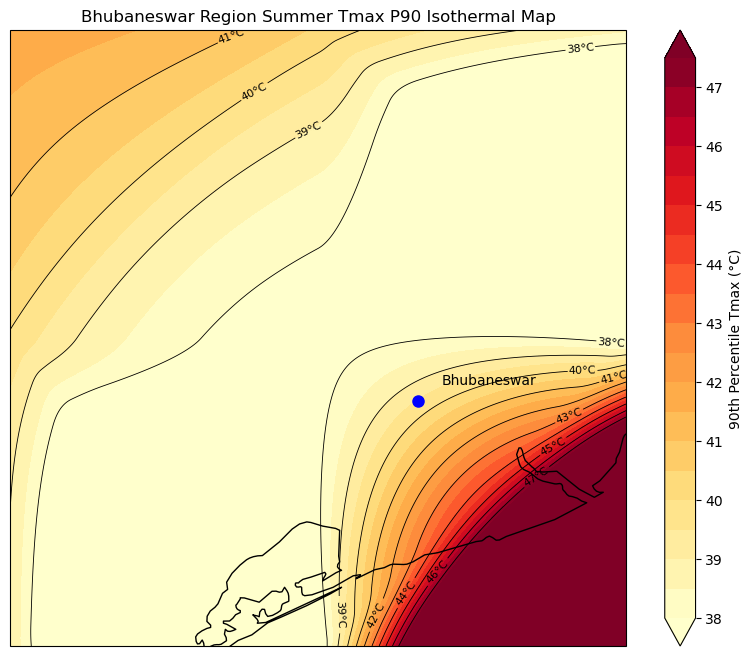

In [40]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(10,8))

ax = plt.axes(
    projection=ccrs.PlateCarree()
)

cf = ax.contourf(
    Lon_new,
    Lat_new,
    p90_interp,
    levels=np.arange(38, 48, 0.5),
    cmap='YlOrRd',
    extend='both'
)

cs = ax.contour(
    Lon_new,
    Lat_new,
    p90_interp,
    levels=np.arange(38, 48, 1),
    colors='black',
    linewidths=0.6
)

ax.clabel(
    cs,
    fmt='%d°C',
    fontsize=8
)

# Bhubaneswar marker
ax.plot(
    85.8245,
    20.2961,
    'bo',
    markersize=8
)

ax.text(
    85.9,
    20.35,
    'Bhubaneswar'
)

ax.coastlines('10m')

plt.colorbar(
    cf,
    label='90th Percentile Tmax (°C)'
)

plt.title(
    'Bhubaneswar Region Summer Tmax P90 Isothermal Map'
)

plt.show()

In [41]:
climatology = (
    bbsr['tmax']
    .groupby('time.dayofyear')
    .mean()
)

In [42]:
tmax_2024 = bbsr['tmax'].sel(
    time=slice('2024-01-01','2024-12-31')
)

anomaly = (
    tmax_2024.groupby('time.dayofyear')
    - climatology
)

In [43]:
import numpy as np

colors = np.where(
    anomaly >= 0,
    'darkred',
    'steelblue'
)

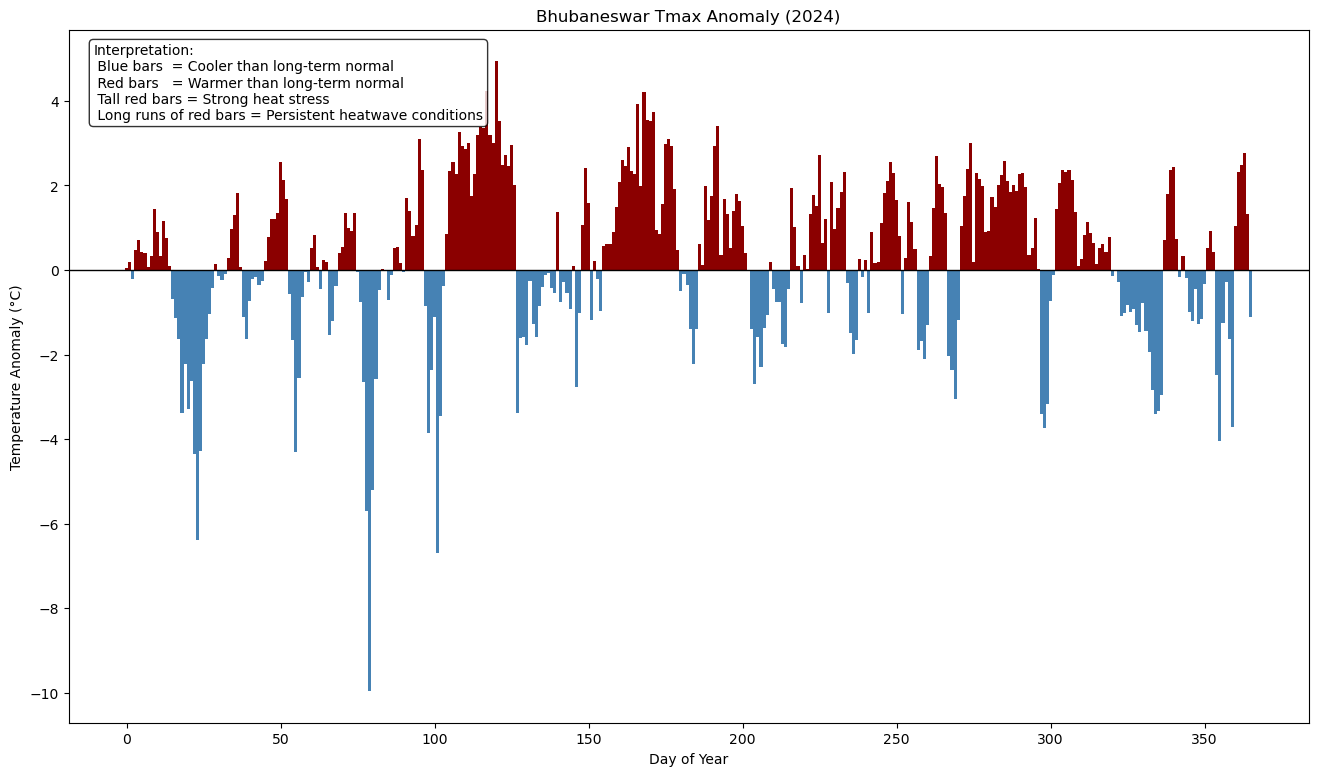

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,9))

plt.bar(
    range(len(anomaly)),
    anomaly.values,
    color=colors,
    width=1
)

plt.axhline(
    0,
    color='black',
    linewidth=1
)

plt.title(
    'Bhubaneswar Tmax Anomaly (2024)'
)

plt.ylabel(
    'Temperature Anomaly (°C)'
)

plt.xlabel(
    'Day of Year'
)

plt.text(
    0.02, 0.98,
    "Interpretation:\n"
    " Blue bars  = Cooler than long-term normal\n"
    " Red bars   = Warmer than long-term normal\n"
    " Tall red bars = Strong heat stress\n"
    " Long runs of red bars = Persistent heatwave conditions",
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(
        boxstyle='round',
        facecolor='white',
        alpha=0.8
    )
)

plt.show()